## 1 · Imports & configuration

In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork)   # combiner les plots ggplot2

source("functions_linear.R")

DATASET_PATH <- "/Volumes/My Passport/NEWMOB/clean_dataset.csv"
FPS          <- 30
COLOR_A      <- "#2E86AB"
COLOR_B      <- "#E84855"

theme_set(theme_bw(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        plot.title = element_text(size = 12)))


Attachement du package : ‘dplyr’


Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union




✔ Fonctions R chargées : run_linear, run_mixed_linear_panel


## 2 · Chargement du dataset

In [2]:
df_raw <- read.csv(DATASET_PATH, stringsAsFactors = FALSE)
cat(sprintf("Dataset brut : %s lignes x %d colonnes\n",
            format(nrow(df_raw), big.mark = ","), ncol(df_raw)))
cat(sprintf("Trajets      : %d\n", n_distinct(df_raw$source)))
head(df_raw, 4)

Dataset brut : 346,426 lignes x 61 colonnes
Trajets      : 25


,source,frame,speed_kmh,gyrz_deg_s,n_vru_total,n_pedestrians,n_cyclists,n_escooters,prop_vru_pedestrian,prop_vru_cyclist,⋯,pct_stationary,pct_gait_standing,pct_gait_walking,pct_gait_running,pct_gait_unknown,pct_age_child,pct_age_adult,pct_age_elderly,pct_age_unknown,pct_unknown_interaction
,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,22.2,25.9,63,0,11.1,7.4,85.2,7.4,0,0
2,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,22.2,25.9,63,0,11.1,7.4,85.2,7.4,0,0
3,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,22.2,25.9,63,0,11.1,7.4,85.2,7.4,0,0
4,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,22.2,25.9,63,0,11.1,7.4,85.2,7.4,0,0


## 3 · Réduction à 1 Hz

Le dataset est échantillonné à 30 FPS. On regroupe par **seconde** (`second = frame %/% 30`) :

In [3]:
df_1hz <- df_raw %>%
  mutate(second = frame %/% FPS) %>%
  group_by(source, second) %>%
  summarise(
    speed_kmh              = mean(speed_kmh,                          na.rm = TRUE),
    rider_id               = first(rider_id),
    n_pedestrians          = max(n_pedestrians,                       na.rm = TRUE),
    road_width_perp_m      = mean(road_width_perp_m,                  na.rm = TRUE),
    hour                   = first(hour),
    day_of_week            = first(day_of_week),
    day_name               = first(day_name),
    is_weekend             = first(is_weekend),
    time_of_day            = first(time_of_day),
    month                  = first(month),
    season                 = first(season),
    genre                  = first(genre),
    age                    = first(age),
    experience             = first(experience),
    distance_km            = first(distance_km),
    start_crossing         = first(start_crossing),
    .groups = "drop"
  ) %>%
  arrange(source, second) %>%
  group_by(source) %>%
  mutate(speed_kmh_t1 = lead(speed_kmh)) %>%   # vitesse à t+1
  ungroup()

cat(sprintf("Après réduction 1 Hz : %s secondes — %d trajets\n",
            format(nrow(df_1hz), big.mark = ","),
            n_distinct(df_1hz$source)))
summary(df_1hz)

Après réduction 1 Hz : 1,271 secondes — 25 trajets


    source              second        speed_kmh        rider_id        
 Length:1271        Min.   :  0.0   Min.   : 2.018   Length:1271       
 Class :character   1st Qu.: 15.5   1st Qu.: 9.293   Class :character  
 Mode  :character   Median : 39.0   Median :12.134   Mode  :character  
                    Mean   : 52.5   Mean   :14.854                     
                    3rd Qu.: 77.0   3rd Qu.:20.706                     
                    Max.   :202.0   Max.   :33.850                     
                                    NA's   :29                         
 n_pedestrians    road_width_perp_m       hour        day_of_week   
 Min.   : 0.000   Min.   :  0.0371   Min.   : 5.00   Min.   :0.000  
 1st Qu.: 1.000   1st Qu.:  8.3412   1st Qu.: 6.00   1st Qu.:2.000  
 Median : 3.000   Median : 11.1569   Median :10.00   Median :3.000  
 Mean   : 3.395   Mean   : 16.9022   Mean   :10.66   Mean   :3.152  
 3rd Qu.: 5.000   3rd Qu.: 22.6462   3rd Qu.:13.00   3rd Qu.:4.000  
 Max.   :1

## 4 · Variable dépendante : `speed_kmh_t1`

Observations totales : 1,175
  Vitesse moyenne : 15.08 km/h
  Vitesse médiane : 12.26 km/h
  Écart-type      : 7.61 km/h
  Min / Max       : 2.36 / 33.85 km/h


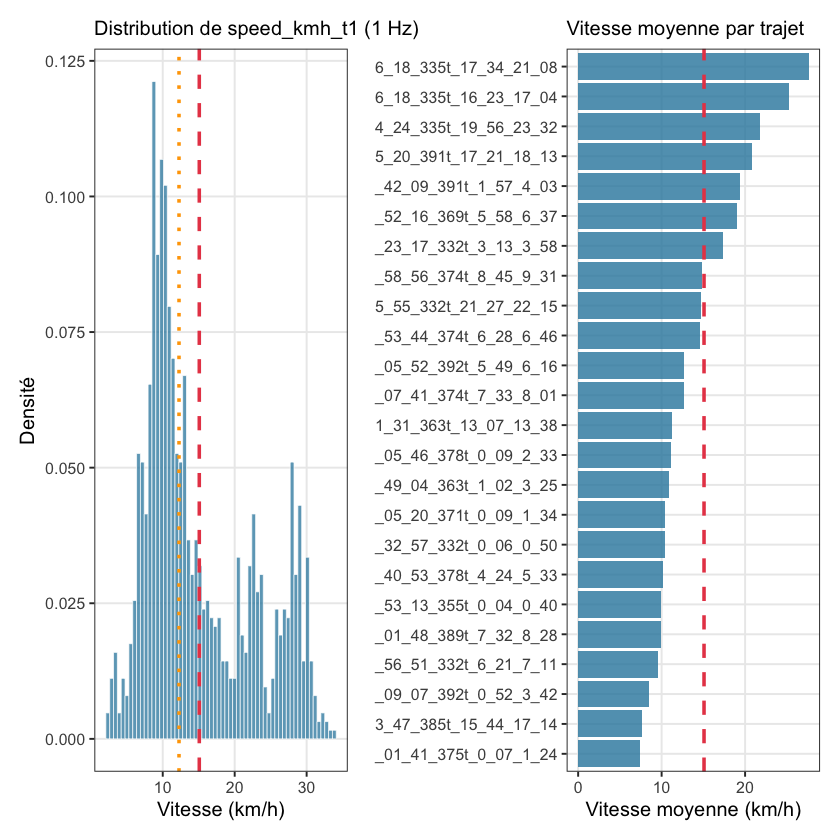

In [4]:
df_model <- df_1hz %>%
  filter(!is.na(speed_kmh_t1), !is.na(n_pedestrians), !is.na(road_width_perp_m)) %>%
  mutate(rider_id_num = as.integer(factor(rider_id)))

cat(sprintf("Observations totales : %s\n", format(nrow(df_model), big.mark = ",")))
cat(sprintf("  Vitesse moyenne : %.2f km/h\n", mean(df_model$speed_kmh_t1)))
cat(sprintf("  Vitesse médiane : %.2f km/h\n", median(df_model$speed_kmh_t1)))
cat(sprintf("  Écart-type      : %.2f km/h\n", sd(df_model$speed_kmh_t1)))
cat(sprintf("  Min / Max       : %.2f / %.2f km/h\n",
            min(df_model$speed_kmh_t1), max(df_model$speed_kmh_t1)))

p1 <- ggplot(df_model, aes(x = speed_kmh_t1)) +
  geom_histogram(aes(y = after_stat(density)), bins = 60,
                 fill = COLOR_A, alpha = 0.75, color = "white", linewidth = 0.2) +
  geom_vline(aes(xintercept = mean(speed_kmh_t1)), color = COLOR_B,
             linetype = "dashed", linewidth = 1) +
  geom_vline(aes(xintercept = median(speed_kmh_t1)), color = "orange",
             linetype = "dotted", linewidth = 1) +
  labs(x = "Vitesse (km/h)", y = "Densité",
       title = "Distribution de speed_kmh_t1 (1 Hz)")

speed_by_traj <- df_model %>%
  group_by(source) %>%
  summarise(mean_speed = mean(speed_kmh_t1), .groups = "drop") %>%
  arrange(mean_speed) %>%
  mutate(source_short = substr(source, nchar(source) - 20, nchar(source)))

p2 <- ggplot(speed_by_traj, aes(x = mean_speed, y = reorder(source_short, mean_speed))) +
  geom_col(fill = COLOR_A, alpha = 0.8) +
  geom_vline(xintercept = mean(df_model$speed_kmh_t1),
             color = COLOR_B, linetype = "dashed", linewidth = 1) +
  labs(x = "Vitesse moyenne (km/h)", y = NULL, title = "Vitesse moyenne par trajet")

p1 + p2

## 5 · Standardisation & création de dummies

In [5]:
# ── Variables continues à standardiser ───────────────────────────────────────
cont_vars <- c("n_pedestrians", "road_width_perp_m", "hour", "age", "distance_km")
cont_vars <- cont_vars[cont_vars %in% names(df_model)]

# Stocker moyennes et écarts-types pour les effets marginaux
means_ <- sapply(cont_vars, function(v) mean(df_model[[v]], na.rm = TRUE))
stds_  <- sapply(cont_vars, function(v) sd(df_model[[v]],   na.rm = TRUE))

for (v in cont_vars) {
  if (!is.na(stds_[v]) && stds_[v] != 0) {
    df_model[[paste0("z_", v)]] <- (df_model[[v]] - means_[v]) / stds_[v]
  } else {
    df_model[[paste0("z_", v)]] <- 0
    warning(sprintf("  %s a un écart-type nul", v))
  }
}

cat("Statistiques des z-scores :\n")
z_cols <- paste0("z_", cont_vars)
print(summary(df_model[, z_cols]))

# ── Variables catégorielles ───────────────────────────────────────────────────
# On garde les variables brutes comme facteurs — R gère les dummies en interne
# Catégories de référence : niveau le plus fréquent (drop_first equivalent)
set_ref <- function(df, col) {
  ref <- names(sort(table(df[[col]]), decreasing = TRUE))[1]
  df[[col]] <- relevel(factor(df[[col]]), ref = ref)
  df
}

cat_vars <- c("rider_id", "day_of_week", "day_name", "is_weekend",
              "time_of_day", "month", "season", "genre", "experience",
              "start_crossing")
cat_vars <- cat_vars[cat_vars %in% names(df_model)]

for (v in cat_vars) {
  df_model <- set_ref(df_model, v)
  cat(sprintf("  %-20s → %d niveaux  (réf = '%s')\n",
              v, nlevels(df_model[[v]]),
              levels(df_model[[v]])[1]))
}

Statistiques des z-scores :
 z_n_pedestrians   z_road_width_perp_m     z_hour            z_age        
 Min.   :-1.2374   Min.   :-1.2209     Min.   :-1.5498   Min.   :-1.3268  
 1st Qu.:-0.8825   1st Qu.:-0.6179     1st Qu.:-1.2681   1st Qu.:-0.6831  
 Median :-0.1728   Median :-0.4157     Median :-0.1410   Median :-0.6027  
 Mean   : 0.0000   Mean   : 0.0000     Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.5370   3rd Qu.: 0.4198     3rd Qu.: 0.7043   3rd Qu.: 1.4087  
 Max.   : 3.7310   Max.   : 6.2375     Max.   : 2.6766   Max.   : 1.4087  
 z_distance_km     
 Min.   :-1.46632  
 1st Qu.:-1.00140  
 Median : 0.01676  
 Mean   : 0.00000  
 3rd Qu.: 1.05783  
 Max.   : 2.04550  
  rider_id             → 15 niveaux  (réf = '335t_vague2')
  day_of_week          → 7 niveaux  (réf = '4')
  day_name             → 7 niveaux  (réf = 'Friday')
  is_weekend           → 2 niveaux  (réf = 'False')
  time_of_day          → 4 niveaux  (réf = 'Morning')
  month                → 4 niveaux  (réf 

## 6 · Modèles

### Modèle 0 — Constante seule

`speed_kmh_t1 = MU + epsilon`

In [6]:
all_results <- list()

r0 <- run_linear(df_model, "1", "M0_null")
all_results[["M0_null"]] <- r0$metrics


  Modèle nul      : LL=-4052.04
  Modèle principal: N=1175  K=2  LL=-4052.04
  rho²=0.0000  AIC=8108.1  BIC=8118.2
  LRT vs nul : chi²(0)=-0.00  p=NA (n.s.)
            Estimate Std. Error  t value Pr(>|t|)
(Intercept) 15.07969  0.2221335 67.88567        0


### Modèle 1 — Piétons

`speed_kmh_t1 = MU + beta_ped * z_n_pedestrians + epsilon`

**Hypothèse :** plus il y a de piétons, plus la vitesse est réduite (beta attendu négatif).

In [7]:
r1 <- run_linear(df_model, "z_n_pedestrians", "M1_pedestrians")
all_results[["M1_pedestrians"]] <- r1$metrics


  Modèle nul      : LL=-4052.04
  Modèle principal: N=1175  K=3  LL=-3903.87
  rho²=0.0366  AIC=7813.7  BIC=7828.9
  LRT vs nul : chi²(1)=296.35  p=0.0000 ***
                 Estimate Std. Error   t value     Pr(>|t|)
(Intercept)     15.079686  0.1958988  76.97693 0.000000e+00
z_n_pedestrians -3.595083  0.1959822 -18.34393 2.815574e-66


### Modèle 2 — Piétons + Largeur de route

In [8]:
r2 <- run_linear(df_model,
                 "z_n_pedestrians + z_road_width_perp_m",
                 "M2_ped_width")
all_results[["M2_ped_width"]] <- r2$metrics


  Modèle nul      : LL=-4052.04
  Modèle principal: N=1175  K=4  LL=-3902.55
  rho²=0.0369  AIC=7813.1  BIC=7833.4
  LRT vs nul : chi²(2)=298.98  p=0.0000 ***
                      Estimate Std. Error    t value     Pr(>|t|)
(Intercept)         15.0796857  0.1957634  77.030169 0.000000e+00
z_n_pedestrians     -3.4996019  0.2045275 -17.110670 9.233152e-59
z_road_width_perp_m -0.3312504  0.2045275  -1.619589 1.055897e-01


### Modèle 3 — Piétons + Genre + Expérience + Moment de la journée + Âge

In [11]:
r3 <- run_linear(df_model,
                 "z_n_pedestrians + genre + time_of_day ",
                 "M3_ped_genre_exp")
all_results[["M3_ped_genre_exp"]] <- r3$metrics


  Modèle nul      : LL=-4052.04
  Modèle principal: N=1175  K=7  LL=-3703.06
  rho²=0.0861  AIC=7420.1  BIC=7455.6
  LRT vs nul : chi²(5)=697.97  p=0.0000 ***
                      Estimate Std. Error    t value     Pr(>|t|)
(Intercept)          19.687123  0.2836557  69.405001 0.000000e+00
z_n_pedestrians      -1.753991  0.1956962  -8.962824 1.224391e-18
genrefemale          -7.401386  0.3563843 -20.767992 8.550758e-82
time_of_dayAfternoon -2.830378  0.3905080  -7.247938 7.671093e-13
time_of_dayEvening    1.793182  1.7333526   1.034517 3.011087e-01
time_of_dayNight     -1.337814  1.2645656  -1.057924 2.903087e-01


### Modèle 4 — Mixte panel (intercept aléatoire par rider)

In [15]:
r4 <- run_mixed_linear_panel(
  df_model,
  rhs          = "genre + hour + road_width_perp_m",
  model_name   = "M4_mixed",
  panel_id_col = "rider_id"
)
all_results[["M4_mixed"]] <- r4$metrics


  Mixed panel linear model: M4_mixed
  Riders=15  Observations=1175
  sigma_rider=4.2473  sigma_eps=3.6873
  Modèle nul      : LL=-3246.83
  Modèle principal: K=6  LL=-3232.59
  rho²=0.0044  AIC=6477.2  BIC=6507.6
  LRT vs nul : chi²(3)=28.47  p=0.0000 ***
                     Estimate Std. Error         df   t value     Pr(>|t|)
(Intercept)       18.97692721 1.83588206   30.32901 10.336681 1.857095e-11
genrefemale       -5.01654978 2.22356484   15.14373 -2.256084 3.927059e-02
hour              -0.33878936 0.08999133  940.73546 -3.764689 1.770968e-04
road_width_perp_m  0.02797332 0.01012507 1174.10609  2.762778 5.820667e-03


In [16]:
ranova(r4$fit)


,npar,logLik,AIC,LRT,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
<none>,6,-3232.589,6477.178,NA,NA,NA
(1 | rider_id),5,-3663.176,7336.351,861.173,1,2.707369e-189


## 7 · Comparaison des modèles

In [11]:
comparison <- bind_rows(all_results) %>%
  mutate(Model = names(all_results)) %>%
  select(Model, N, K, LL_null, LL_final, rho2, rho2_bar, AIC, BIC, LRT_stat, LRT_df, LRT_p)

knitr::kable(comparison, digits = 4, format.args = list(big.mark = ","))



|Model            |     N|  K|   LL_null|  LL_final|   rho2| rho2_bar|      AIC|      BIC| LRT_stat| LRT_df| LRT_p|
|:----------------|-----:|--:|---------:|---------:|------:|--------:|--------:|--------:|--------:|------:|-----:|
|M0_null          | 1,175|  2| -4,052.04| -4,052.04| 0.0000|  -0.0005| 8,108.09| 8,118.23|     0.00|      0|    NA|
|M1_pedestrians   | 1,175|  3| -4,052.04| -3,903.87| 0.0366|   0.0358| 7,813.74| 7,828.94|   296.35|      1|     0|
|M2_ped_width     | 1,175|  4| -4,052.04| -3,902.55| 0.0369|   0.0359| 7,813.11| 7,833.39|   298.98|      2|     0|
|M3_ped_genre_exp | 1,175| 11| -4,052.04| -3,546.92| 0.1247|   0.1219| 7,115.84| 7,171.60| 1,010.25|      9|     0|
|M4_mixed         | 1,175| 12| -3,246.83| -3,203.99| 0.0132|   0.0095| 6,431.98| 6,492.80|    85.68|      9|     0|

In [12]:
# LR-tests emboîtés
lr_test <- function(res_r, res_f) {
  ll_r <- res_r$metrics$LL_final
  ll_f <- res_f$metrics$LL_final
  k_r  <- res_r$metrics$K
  k_f  <- res_f$metrics$K
  lr   <- -2 * (ll_r - ll_f)
  dk   <- k_f - k_r
  p    <- if (dk > 0) pchisq(lr, df = dk, lower.tail = FALSE) else NA
  c(LR = round(lr, 2), delta_k = dk, p = round(p, 4))
}

cat("\nLR-tests (modèles emboîtés) :\n")
cat(sprintf("  M0 → M1 : %s\n", paste(lr_test(r0, r1), collapse = "  ")))
cat(sprintf("  M1 → M2 : %s\n", paste(lr_test(r1, r2), collapse = "  ")))
cat(sprintf("  M2 → M3 : %s\n", paste(lr_test(r2, r3), collapse = "  ")))
cat(sprintf("  M3 → M4 : %s\n", paste(lr_test(r3, r4), collapse = "  ")))


LR-tests (modèles emboîtés) :
  M0 → M1 : 296.34  1  0
  M1 → M2 : 2.64  1  0.1042
  M2 → M3 : 711.26  7  0
  M3 → M4 : 685.86  1  0


## 8 · Effets marginaux (M3)

Pour un modèle **linéaire**, l'effet marginal = coefficient / écart-type de la variable originale.

In [14]:
coefs <- coef(r3$fit)
mu_val <- coefs["(Intercept)"]

var_map <- list(
  list(beta = "z_n_pedestrians",  raw = "n_pedestrians",    unit = "piéton(s)"),
  list(beta = "z_road_width_perp_m", raw = "road_width_perp_m", unit = "mètre(s)"),
  list(beta = "z_age",            raw = "age",              unit = "an(s)")
)

me_rows <- lapply(var_map, function(x) {
  beta_z     <- coefs[x$beta]
  sd_raw     <- stds_[x$raw]
  me_per_unit <- if (!is.na(beta_z) && !is.na(sd_raw)) beta_z / sd_raw else NA
  data.frame(Variable        = x$raw,
             `beta_z (km/h/σ)` = round(beta_z, 4),
             `ME (km/h/unité)` = round(me_per_unit, 5),
             Unité            = x$unit,
             check.names = FALSE)
})

me_df <- bind_rows(me_rows)
cat("Effets marginaux — M3 :\n")
print(me_df)

ggplot(me_df, aes(x = `ME (km/h/unité)`, y = Variable,
                  fill = `ME (km/h/unité)` >= 0)) +
  geom_col(alpha = 0.8) +
  scale_fill_manual(values = c("TRUE" = COLOR_A, "FALSE" = COLOR_B), guide = "none") +
  geom_vline(xintercept = 0, linetype = "dashed", linewidth = 1) +
  labs(x = "Effet marginal (km/h par unité originale)",
       title = "Effets marginaux — M3") +
  theme(legend.position = "none")

ERROR: Error in data.frame(Variable = x$raw, `beta_z (km/h/σ)` = round(beta_z, : les noms de lignes contiennent des valeurs manquantes


## 9 · Courbes de prédiction (M3)

Chaque graphique fait varier **une variable** sur son étendue (p2–p98),
toutes les autres maintenues à leur moyenne (z = 0).

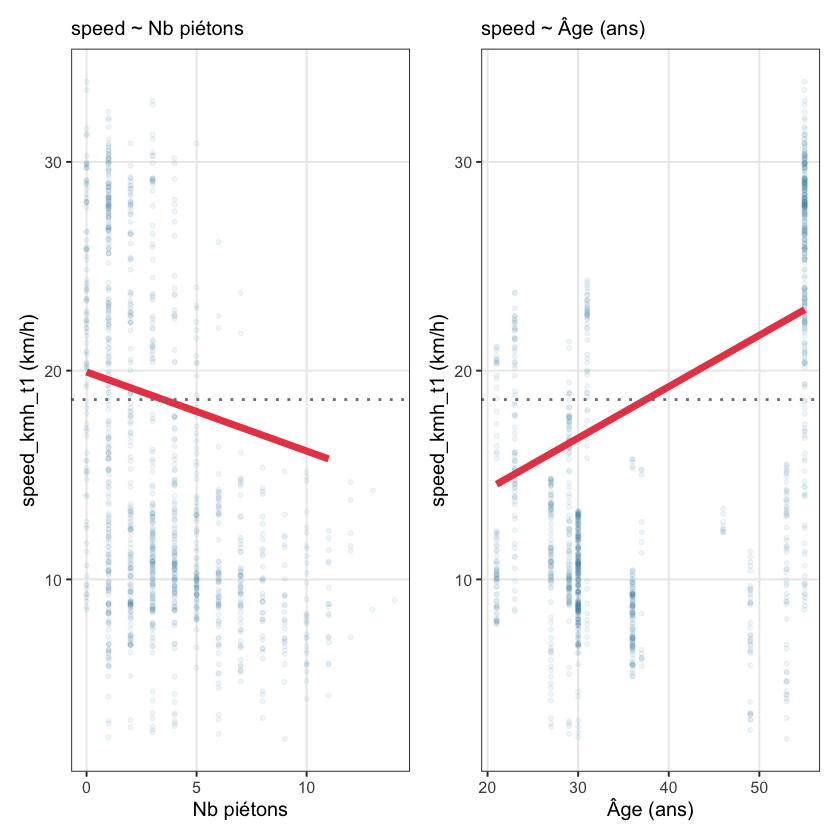

In [14]:
vars_plot <- list(
  list(beta = "z_n_pedestrians",  raw = "n_pedestrians",    label = "Nb piétons"),
  list(beta = "z_road_width_perp_m", raw = "road_width_perp_m", label = "Largeur route (m)"),
  list(beta = "z_age",            raw = "age",              label = "Âge (ans)")
)

plots_pred <- lapply(vars_plot, function(v) {
  if (!(v$raw %in% names(df_model))) return(NULL)
  beta_val <- coefs[v$beta]
  if (is.na(beta_val)) return(NULL)

  x_raw <- seq(quantile(df_model[[v$raw]], 0.02, na.rm = TRUE),
               quantile(df_model[[v$raw]], 0.98, na.rm = TRUE),
               length.out = 200)
  x_z    <- (x_raw - means_[v$raw]) / stds_[v$raw]
  y_pred <- mu_val + beta_val * x_z

  pred_df  <- data.frame(x = x_raw, y = y_pred)
  obs_df   <- df_model[, c(v$raw, "speed_kmh_t1")] %>%
              rename(x = 1, y = speed_kmh_t1) %>%
              filter(!is.na(x), !is.na(y))

  ggplot() +
    geom_point(data = obs_df,  aes(x = x, y = y),
               alpha = 0.07, size = 1, color = COLOR_A) +
    geom_line(data  = pred_df, aes(x = x, y = y),
              color = COLOR_B, linewidth = 2) +
    geom_hline(yintercept = mu_val, linetype = "dotted",
               color = "gray50", linewidth = 0.8) +
    labs(x = v$label, y = "speed_kmh_t1 (km/h)",
         title = paste("speed ~", v$label))
})

plots_pred <- Filter(Negate(is.null), plots_pred)
wrap_plots(plots_pred, nrow = 1)

## 10 · Diagnostic des résidus (M3)

R² (OLS) — M3 : 0.5767
RMSE — M3      : 4.952 km/h

Test Shapiro-Wilk (n=1175) : stat=0.9753, p=2.8296e-13


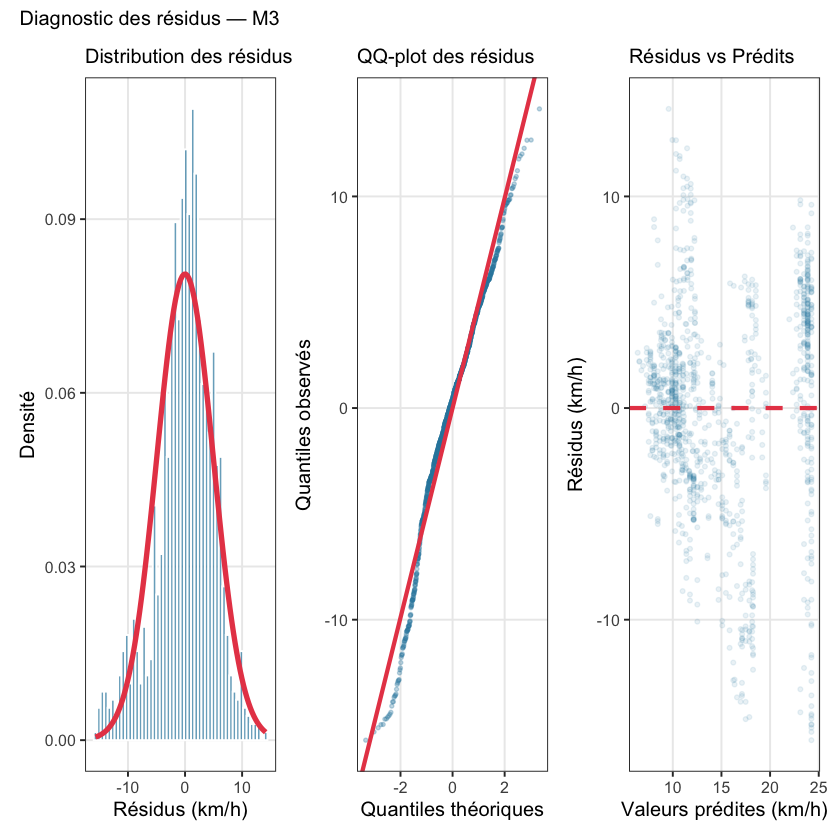

In [15]:
data_m3 <- df_model %>%
  select(speed_kmh_t1, z_n_pedestrians, z_road_width_perp_m, z_age,
         genre, experience, time_of_day) %>%
  filter(complete.cases(.))

y_pred_m3 <- predict(r3$fit, newdata = data_m3)
residuals  <- data_m3$speed_kmh_t1 - y_pred_m3

ss_res <- sum(residuals^2)
ss_tot <- sum((data_m3$speed_kmh_t1 - mean(data_m3$speed_kmh_t1))^2)
r2_ols <- 1 - ss_res / ss_tot
rmse   <- sqrt(mean(residuals^2))

cat(sprintf("R² (OLS) — M3 : %.4f\n", r2_ols))
cat(sprintf("RMSE — M3      : %.3f km/h\n", rmse))

resid_df <- data.frame(y_pred = y_pred_m3, resid = residuals)

# 1. Distribution des résidus
p_hist <- ggplot(resid_df, aes(x = resid)) +
  geom_histogram(aes(y = after_stat(density)), bins = 50,
                 fill = COLOR_A, alpha = 0.7, color = "white") +
  stat_function(fun = dnorm, args = list(mean = 0, sd = sd(residuals)),
                color = COLOR_B, linewidth = 1.5) +
  labs(x = "Résidus (km/h)", y = "Densité", title = "Distribution des résidus")

# 2. QQ-plot
qq_data <- data.frame(
  sample    = sort(residuals),
  theorical = qnorm(ppoints(length(residuals)))
)
p_qq <- ggplot(qq_data, aes(x = theorical, y = sample)) +
  geom_point(alpha = 0.3, size = 0.8, color = COLOR_A) +
  geom_abline(slope = sd(residuals), intercept = 0,
              color = COLOR_B, linewidth = 1.2) +
  labs(x = "Quantiles théoriques", y = "Quantiles observés",
       title = "QQ-plot des résidus")

# 3. Résidus vs valeurs prédites
p_rv <- ggplot(resid_df, aes(x = y_pred, y = resid)) +
  geom_point(alpha = 0.1, size = 1, color = COLOR_A) +
  geom_hline(yintercept = 0, color = COLOR_B, linetype = "dashed", linewidth = 1.2) +
  labs(x = "Valeurs prédites (km/h)", y = "Résidus (km/h)",
       title = "Résidus vs Prédits")

(p_hist | p_qq | p_rv) +
  plot_annotation(title = "Diagnostic des résidus — M3")

# Test de normalité Shapiro-Wilk (sous-échantillon)
n_test   <- min(5000, length(residuals))
sw_result <- shapiro.test(sample(residuals, n_test))
cat(sprintf("\nTest Shapiro-Wilk (n=%d) : stat=%.4f, p=%.4e\n",
            n_test, sw_result$statistic, sw_result$p.value))

## 11 · Visualisation comparaison des modèles

In [16]:
comp_long <- comparison %>%
  select(Model, rho2, rho2_bar, AIC, BIC) %>%
  pivot_longer(-Model, names_to = "metric", values_to = "value")

p_rho <- comparison %>%
  select(Model, rho2, rho2_bar) %>%
  pivot_longer(-Model) %>%
  ggplot(aes(x = reorder(Model, value), y = value, fill = name)) +
  geom_col(position = "identity", alpha = 0.7) +
  scale_fill_manual(values = c("rho2" = COLOR_A, "rho2_bar" = "#5BC0EB")) +
  coord_flip() +
  labs(x = NULL, y = "rho²", title = "rho² de McFadden", fill = NULL)

p_aic <- ggplot(comparison, aes(x = reorder(Model, AIC), y = AIC)) +
  geom_col(fill = COLOR_B, alpha = 0.8) +
  coord_flip() +
  labs(x = NULL, y = "AIC", title = "AIC (bas = meilleur)")

p_bic <- ggplot(comparison, aes(x = reorder(Model, BIC), y = BIC)) +
  geom_col(fill = "#F4A261", alpha = 0.8) +
  coord_flip() +
  labs(x = NULL, y = "BIC", title = "BIC (bas = meilleur)")

(p_rho | p_aic | p_bic) +
  plot_annotation(title = "Comparaison modèles linéaires — VD : speed_kmh_t1")

ERROR: Error: objet 'comparison' introuvable


## 12 · Synthèse

### Lecture des coefficients

| Signe beta | Interprétation |
|------------|----------------|
| beta > 0 | la variable est **associée à une vitesse plus élevée** |
| beta < 0 | la variable est **associée à une vitesse plus faible** |

**Unité :** les coefficients sur les z-scores = **km/h par écart-type** de la variable.

### Comparaison Python → R

| Aspect | Python (Biogeme) | **R (lm / lmer)** |
|--------|------------------|--------------------|
| Modèle fixe | MLE gaussien (Biogeme) | OLS = `lm()` (identique) |
| Modèle mixte | Monte-Carlo panel | REML/ML = `lmer()` (lme4) |
| P-valeurs mixte | non disponibles | Satterthwaite (lmerTest) |
| Formule | expression Biogeme | chaîne R standard |